# Phase 1 — GENCLS on SMIB

**Classical synchronous machine, swing equation, single-machine infinite-bus.**

This notebook is the colleague-facing artefact for Phase 1.  Read it
top-to-bottom as a teaching script: the physics first, then the
simulator output, then a slider-driven exploration of inertia and
clearing-time trade-offs.

> **Read these foundations docs first** — they carry the conceptual
> content that lets every cell below make sense:
>
> - [`docs/genrou_physical_foundations.md`](../docs/genrou_physical_foundations.md)
>   — what each synchronous-machine parameter physically represents
>   ($X_d$/$X'_d$/$X''_d$ hierarchy, $T'_{d0}$ as the field winding's
>   $L/R$, leakage $X_l$, saturation), with d-axis equivalent
>   circuits and the three reactance regimes over time.  GENCLS in
>   this notebook is the limit case of GENROU with $T'_{d0} \to \infty$
>   — the *constant flux linkage* approximation pinned forever.
>
> - [`docs/network_machine_interface.md`](../docs/network_machine_interface.md)
>   — how the simulator stitches per-machine differential equations
>   (in each rotor's rotating dq frame) to the algebraic network
>   solve (in the stationary system DQ frame).  The rotation
>   $X_\text{machine} = X_\text{global}\cdot e^{-j\delta}$, the
>   partitioned solver scheme, the Norton-augmented Y_bus trick,
>   and the PSSE/Kundur dq sign convention used throughout this
>   notebook.  In particular, we use **q-axis aligned with $E'$,
>   d-axis 90° behind in the direction of rotation**, so $I_q > 0$
>   is the torque-producing component and $I_d > 0$ is the
>   demagnetising lagging-PF component.

Sequence:

1. The swing equation, derived from first principles
2. Imports
3. The network model (Ybus, infinite bus, fault as shunt)
4. Power flow (what `two_bus_pf` does, why the bus type matters,
   the NR iteration trace, and the SLD of the converged state)
5. Initialisation, step by step (the equations behind `gencls.initialise`)
6. Algebraic power equations + P-δ curve + equal-area criterion
7. Flat-line correctness floor
8. Three-phase fault, recovery, walked through the swing equation
9. Critical clearing time — analytic (EAC) vs simulator
10. Under the hood — solver flowchart per timestep
11. Interactive: sweep `H` and fault duration
12. What's missing (Phase 2 onward)

Pre-requisite: run `bash setup.sh` once at the smib repo root to create
the venv and install dependencies. Re-launch in the future via
`start_notebook.command` (double-click in Finder).

## 1. Swing equation

Start with Newton's second law applied to the machine rotor, in
mechanical radians:

$$ J \frac{d\omega_m}{dt} = T_m - T_e $$

Multiply through by $\omega_m$ to get power instead of torque, and
non-dimensionalise time by $\omega_0$ (the synchronous angular
frequency, in electrical rad/s).  Defining the inertia constant

$$ H = \frac{\tfrac{1}{2} J \omega_{m0}^2}{S_{\text{base}}} \quad [\text{seconds}] $$

and the per-unit slip $\bar\omega = (\omega - \omega_0)/\omega_0$, the
swing equation collapses to

$$ \boxed{\;2H\,\frac{d\bar\omega}{dt} = P_m - P_e - D\,\bar\omega\;} $$
$$ \boxed{\;\frac{d\delta}{dt} = \omega_0\,\bar\omega\;} $$

The classical (GENCLS) model holds the internal EMF $|E'|$ constant
behind the transient reactance $X'_d$.  The electrical power output
to the network is

$$ P_e = \mathrm{Re}\big(V \cdot I^*\big), \qquad I = (E' - V) / (j X'_d) $$

with $E' = |E'|\,e^{j\delta}$ in the global synchronous DQ frame.

Two states.  Two equations.  No flux dynamics, no controllers.  This
is the simplest dynamic generator model and the right starting point
for transient stability — every concept (rotor angle, equal-area
criterion, critical clearing time) appears here in its purest form.


## 2. Imports

The bootstrap cell makes sure Python can find the `smib` package even
if the kernel was launched from inside the `notebooks/` folder.  It is
a no-op once you have installed the package via `pip install -e .` at
the repo root, but it costs nothing to keep.

In [1]:
# Bootstrap: ensure the smib package is importable regardless of where
# the kernel was launched.  Adds the parent of `notebooks/` to sys.path
# if we're inside the notebooks directory.
import sys, pathlib
_here = pathlib.Path.cwd()
_root = _here.parent if _here.name == 'notebooks' else _here
if str(_root) not in sys.path:
    sys.path.insert(0, str(_root))

import math
import numpy as np
import plotly.graph_objects as go

from smib.models import GENCLS
from smib.network import Network
from smib.powerflow import two_bus_pf
from smib.scenarios import three_phase_fault_schedule
from smib.simulator import run_smib_gencls
from smib.plotting import plot_traces, shade_event_window, scenario_slider, plot_sld, CANONICAL

## 3. The network model

Before running any dynamics we need an algebraic network model — given
the current the machine injects, what voltage appears at its
terminals?

For SMIB the network is the simplest possible: one transmission line
of impedance $R + jX$ connecting two buses.

- **Bus 1** — the generator bus (where GENCLS connects).
- **Bus 2** — the **infinite bus**.  A fictional bus that holds its
  voltage perfectly constant in both magnitude and angle no matter
  what current flows through it.  This is a stand-in for *the rest of
  a large interconnected power system*, which is too big for any
  single machine to perturb.  In production studies you would replace
  it with a Thévenin equivalent of the surrounding grid.

The Y-bus matrix encodes this network in admittance form.  For two
buses connected by one line of admittance $y_{\text{line}} = 1/(R+jX)$:

$$ Y_{\text{bus}} = \begin{bmatrix} y_{\text{line}} & -y_{\text{line}} \\ -y_{\text{line}} & y_{\text{line}} \end{bmatrix} $$

The diagonals are the self-admittance at each bus (sum of all branches
incident to it); the off-diagonals are the negative of the line
admittance.  Voltages and current injections relate via the network
equation $\mathbf{I} = Y_{\text{bus}}\,\mathbf{V}$.

When a three-phase fault hits at bus 1 we add a shunt admittance to
$Y_{00}$.  A *bolted* fault has zero impedance — modelled in code as
a very large but finite shunt admittance (1e6 S) so the matrix stays
numerically well-conditioned.  This is exactly the trick PSSE uses.

In [2]:
# Build the network.  Pure reactance line, no resistance, infinite bus
# at 1.0 pu / 0 deg as the system reference.
R_line, X_line = 0.0, 0.5
V_inf = 1.0 + 0j

network = Network(R=R_line, X=X_line, V_slack_mag=abs(V_inf))
print('Ybus =')
print(network.ybus())

Ybus =
[[ 0.-2.j -0.+2.j]
 [-0.+2.j  0.-2.j]]


## 4. Power flow — finding the steady-state operating point

The dynamic simulation needs a starting point — a steady-state where
every voltage and every current is consistent with the network and
with the loading.  That's what power flow does.

For SMIB we have **two unknowns** at the generator bus:
$|V_1|$ (voltage magnitude) and $\angle V_1$ (voltage angle).  We
supply **two equations**: the generator injects a known active power
$P$ and reactive power $Q$.

$$ P_{\text{calc}}(|V_1|, \angle V_1) - P_{\text{spec}} = 0 $$
$$ Q_{\text{calc}}(|V_1|, \angle V_1) - Q_{\text{spec}} = 0 $$

Where, with the slack bus held at $V_\infty = 1\angle 0$:

$$ P_{\text{calc}} = \mathrm{Re}\big( V_1 \cdot I_1^* \big), \qquad
   I_1 = Y_{00} V_1 + Y_{01} V_\infty $$

These are nonlinear in the angle, so we solve them with a small
Newton-Raphson iteration: linearise around the current guess via the
Jacobian $\partial(P,Q)/\partial(|V|, \angle V)$, take a step, repeat
until the mismatch is below tolerance.  For SMIB this converges in
3-5 iterations from a flat start.

The `bus_type` argument matters:

- `'PQ'` — the generator bus is a *constant-power* bus.  Both $P$ and
  $Q$ are specified; both $|V|$ and $\angle V$ are solved for.  This
  is the right choice for GENCLS, which has no AVR and so does not
  regulate voltage.
- `'PV'` — *constant-power-and-voltage* bus.  $P$ and $|V|$ are
  specified; $Q$ and $\angle V$ are solved for.  This is what we will
  switch to in Phase 2 once an AVR is present.

### 4.1 The Newton-Raphson update, mechanically

At iteration $k$ we have a guess $(|V_1|^{(k)}, \theta_1^{(k)})$.  We
compute the calculated injections $P_{\text{calc}}$ and $Q_{\text{calc}}$
from the network equation, then form the **mismatch vector**:

$$ \Delta = \begin{bmatrix} P_{\text{spec}} - P_{\text{calc}} \\ Q_{\text{spec}} - Q_{\text{calc}} \end{bmatrix} $$

If $\|\Delta\|_\infty < $ tolerance, stop.  Otherwise linearise:

$$ \mathbf{J}\,\Delta x = \Delta, \qquad
\mathbf{J} = \begin{bmatrix}
   \partial P_{\text{calc}} / \partial \theta_1 & \partial P_{\text{calc}} / \partial |V_1| \\
   \partial Q_{\text{calc}} / \partial \theta_1 & \partial Q_{\text{calc}} / \partial |V_1|
\end{bmatrix} $$

Solve for $\Delta x = (\Delta\theta_1, \Delta|V_1|)$, update the guess
$\theta_1 \leftarrow \theta_1 + \Delta\theta_1$ and
$|V_1| \leftarrow |V_1| + \Delta|V_1|$, and iterate.  The Jacobian
inside `two_bus_pf` is computed by finite difference for readability;
an analytical Jacobian would be marginally faster but obscures what
each entry means.

We turn on the function's `verbose=True` flag below so you can watch
each iteration converge.  Watch the `|mismatch|` column — it should
shrink **quadratically** near the solution (each iteration roughly
squares the residual).  That quadratic convergence is the hallmark of
Newton's method working correctly.

In [3]:
# Operating point: 0.8 pu active, 0.2 pu reactive injected at the
# generator bus.
P, Q = 0.8, 0.2

V1, iters = two_bus_pf(
    P_spec=P, Q_spec=Q,
    V_slack_mag=abs(V_inf), V_slack_ang=0.0,
    R=R_line, X=X_line,
    bus_type='PQ',
    verbose=True,
)
print()
print(f'V_gen = {abs(V1):.4f} pu, angle = {math.degrees(np.angle(V1)):.3f} deg')

iter       |V1|   angle deg        mis P        mis Q    |mismatch|
   0   1.000000      0.0000    8.000e-01    2.000e-01     8.000e-01
   1   1.100000     22.9183   -5.672e-02   -1.937e-01     1.937e-01
   2   1.023860     22.9913    1.792e-04   -1.152e-02     1.152e-02
   3   1.017829     23.1399    3.149e-05   -6.683e-05     6.683e-05
   4   1.017787     23.1419    3.173e-09   -3.554e-09     3.554e-09
   5   1.017787     23.1419    1.110e-16    2.776e-17     1.110e-16
>>> Converged in 5 iterations to |mismatch| < 1e-10

V_gen = 1.0178 pu, angle = 23.142 deg


### 4.2 Reading the iteration trace

- **Iteration 0** starts from a flat guess: $|V_1| = 1.0$ pu, $\theta_1 = 0$.
  Mismatch is large because the flat guess assumes the generator is
  exporting nothing, but we are actually asking it to push 0.8 pu of
  active power through a 0.5 pu reactance.
- **Iteration 1** takes the first NR step.  Mismatch drops by an order
  of magnitude.
- **Iterations 2-3** finish the convergence.  Notice the mismatch
  squaring at each step (1e-2 → 1e-5 → 1e-10).  That is the quadratic
  convergence of Newton's method around a smooth solution — a
  textbook-clean PF problem.
- **Final iteration** has $|\text{mismatch}|$ below the $10^{-10}$
  tolerance, so we stop and return the converged $V_1$.

The returned **angle is positive** (~+23°) because the generator is
exporting active power.  The terminal voltage phasor leads the
infinite bus.  This is the **load angle at the terminal**, distinct
from the rotor angle $\delta$ that we compute next.  In a stable
transient the rotor will swing forward of this angle during the
disturbance and oscillate back to it afterward.

### 4.3 Single-line diagram of the converged operating point

PSSE renders a one-line diagram (SLD) after every load flow showing
each bus with its converged $|V|$ and $\angle V$, every branch with
its impedance and $P$/$Q$ flow with arrow direction, and
generator/slack symbols on the buses they sit on.  We do the same
here so the operating point can be read at a glance before any
dynamics are touched.

What to verify on this diagram:

- The slack bus shows $|V| = 1.000$ pu, $\angle = 0.000°$ — by
  definition; if it doesn't, the network was set up wrong.
- The generator bus shows the same $|V_1|$ and $\angle V_1$ that NR
  just printed.
- The line flow $P, Q$ matches the generator injection because the
  line is lossless ($R = 0$). On a lossy line you'd see the
  slack-end power slightly less than the gen-end.
- The arrows point from gen-bus to slack-bus, confirming the
  generator is exporting (not absorbing) — exactly what
  $P_{\text{spec}} = +0.8$ implies.

Every phase notebook from here on opens with this diagram for the
case under study, so colleagues never have to mentally reconstruct
the topology and operating point from a wall of code.

In [4]:
fig = plot_sld(
    V_gen=V1, S_gen=complex(P, Q), V_inf=V_inf,
    R_line=R_line, X_line=X_line,
    gen_label='GENCLS',
    title='SMIB single-line diagram (post-LF, pre-disturbance)',
)
fig.show()

## 5. Initialisation — back-calculating the rotor state

Power flow gives us $V_1$ (terminal phasor) and $S = P + jQ$ (terminal
complex power).  Initialisation derives every internal state of the
machine from these two quantities such that **every derivative is zero
at $t=0$**.  If we get this wrong, the simulation drifts the moment we
press *go*, and we spend hours hunting a bug that's actually in the
initial conditions.  This is why every model in `smib` exposes an
`initialise()` method and every simulator entry point checks the
flat-line residual before stepping.

The four-step protocol for GENCLS:

**Step 1.** Compute the terminal current from power and voltage.
Generator convention: $S = V \cdot I^*$, so

$$ I = \overline{\left( S / V \right)} $$

In [5]:
S = complex(P, Q)
I_term = np.conj(S / V1)
print(f'I_terminal = {abs(I_term):.4f} pu, angle = {math.degrees(np.angle(I_term)):.3f} deg')

I_terminal = 0.8102 pu, angle = 9.106 deg


**Step 2.** The internal EMF $E'$ lies behind the transient
reactance $X'_d$.  In phasor form:

$$ E' = V + j X'_d \cdot I $$

This is just KVL across the equivalent circuit: terminal voltage equals
the EMF minus the voltage drop across the transient reactance, with
sign convention chosen so that current flows from the EMF out into the
network.

In [6]:
Xdp = 0.30                       # transient reactance, pu
E_phasor = V1 + 1j * Xdp * I_term

E_mag   = abs(E_phasor)
delta_0 = np.angle(E_phasor)
print(f"|E'|     = {E_mag:.4f} pu      (held constant — no AVR in GENCLS)")
print(f"delta_0  = {math.degrees(delta_0):.3f} deg  (initial rotor angle, global DQ frame)")

|E'|     = 1.1023 pu      (held constant — no AVR in GENCLS)
delta_0  = 35.495 deg  (initial rotor angle, global DQ frame)


**Step 3.** Mechanical power input balances electrical power
output at steady state:

$$ P_m = \mathrm{Re}\big( V \cdot I^* \big) = P $$

Equivalently $P_m = \mathrm{Re}\big( E' \cdot I^* \big)$, since the
transient reactance is purely reactive and dissipates no active power.
Both must yield the same number, and that number must equal the
specified $P$ from the power flow — if it doesn't, the back-EMF
calculation is wrong.

In [7]:
Pm  = float((V1 * np.conj(I_term)).real)
Pm2 = float((E_phasor * np.conj(I_term)).real)
print(f'Pm (from V * I*) = {Pm:.6f} pu')
print(f'Pm (from E * I*) = {Pm2:.6f} pu  (must match)')

Pm (from V * I*) = 0.800000 pu
Pm (from E * I*) = 0.800000 pu  (must match)


**Step 4.** Set the slip $\bar\omega_0 = 0$ — the rotor turns at
exactly synchronous speed at steady state.  No surprise, but worth
stating explicitly because it's the *kinematic* state that closes the
two-state system.

That's the full initialisation by hand.  The `GENCLS.initialise(V, S)`
method does all four steps internally; we call it now and verify it
agrees with the manual derivation.

In [8]:
gencls = GENCLS(H=4.0, D=3.0, Xdp=Xdp, f0=50.0)
gencls.initialise(V1, S)

print('--- GENCLS internal state after initialise() ---')
print(f'delta_0  = {math.degrees(gencls.state["delta"]):.3f} deg     (manual: {math.degrees(delta_0):.3f})')
print(f'omega_0  = {gencls.state["omega"]:.3e} pu       (slip, must be 0)')
print(f"|E'|     = {gencls.params['Eint']:.4f} pu          (manual: {E_mag:.4f})")
print(f'Pm       = {gencls.params["Pm"]:.4f} pu          (manual: {Pm:.4f})')

--- GENCLS internal state after initialise() ---
delta_0  = 35.495 deg     (manual: 35.495)
omega_0  = 0.000e+00 pu       (slip, must be 0)
|E'|     = 1.1023 pu          (manual: 1.1023)
Pm       = 0.8000 pu          (manual: 0.8000)


All four numbers match the hand calculation.  At this point the
machine model is fully primed: any call to `gencls.derivatives()` must
return zero for every state (within machine epsilon).  We verify that
explicitly in §7 — the **flat-line test** — which is the non-negotiable
correctness floor for everything that follows.

But before we run any dynamics, we should establish the algebraic
P-δ and Q-δ relationships that govern *every* SMIB scenario.  Those
two equations are the foundation of transient stability and they
underpin everything in §8 onward.

## 6. The algebraic power equations and the equal-area criterion

Every dynamic state we simulate sits on top of two algebraic
relationships you should know by heart.  For a source $E' = |E'|\angle\delta$
feeding a voltage $V_\infty = |V_\infty|\angle 0$ across a pure
reactance $X_{\text{tot}} = X'_d + X_{\text{line}}$, the active and
reactive power injected at the gen-end are:

$$ \boxed{\;P_e = \dfrac{|E'|\,|V_\infty|}{X_{\text{tot}}}\,\sin\delta\;} $$

$$ \boxed{\;Q_e = \dfrac{|E'|^2 - |E'|\,|V_\infty|\cos\delta}{X_{\text{tot}}}\;} $$

These come straight from $S = V \cdot I^*$ with
$I = (E' - V_\infty)/(j X_{\text{tot}})$ — multiply it out and the
real and imaginary parts give exactly the two boxed expressions.

These two equations carry essentially all the intuition for SMIB
transient stability.  Three consequences:

**1. The synchronising coefficient.**
$K_s = \partial P_e/\partial \delta = (|E'|\,|V_\infty|/X_{\text{tot}})\cos\delta$
— the spring constant of the rotor, restoring torque per unit angle
deviation.  Positive for $\delta < 90°$, zero at exactly 90°,
negative beyond.  This is what closes the small-signal loop and gives
the swing equation its natural frequency
$\omega_n = \sqrt{\omega_0 K_s/(2H)}$.

**2. The maximum power transfer.**
$P_e^{\max} = |E'|\,|V_\infty|/X_{\text{tot}}$ at $\delta = 90°$.
If you ask the machine to push more than this, no steady-state
solution exists — voltage collapse.  This sets the absolute ceiling
for steady-state loading on this network.

**3. Two equilibria for any $P_m < P_e^{\max}$.**  The horizontal
line $P_e = P_m$ cuts the sinusoid at two angles: a **stable**
equilibrium at $\delta_0$ (the operating point) and an **unstable**
equilibrium at $\pi - \delta_0$ where the spring constant is
negative.  If a disturbance pushes $\delta$ past $\pi - \delta_0$,
the rotor pulls out of synchronism and runs away.

In [9]:
\
# Compute the P-delta curve and key landmarks.
omega0 = 2 * math.pi * 50
V_inf_mag = abs(V_inf)
X_tot = Xdp + X_line

Pmax = E_mag * V_inf_mag / X_tot
Pe_at_op = Pmax * math.sin(delta_0)            # delta_0 from §5
Ks = Pmax * math.cos(delta_0)
delta_unst = math.pi - delta_0

print(f'P_e^max  = E·V/X = {E_mag:.4f} · {V_inf_mag:.4f} / {X_tot:.4f} = {Pmax:.4f} pu')
print(f'P_e(δ_0) = {Pe_at_op:.4f} pu     (must equal Pm = {Pm:.4f}, since steady state)')
print(f'K_s      = (EV/X)·cos(δ_0) = {Ks:.4f} pu/rad')
print(f'Stable equilibrium   δ_0    = {math.degrees(delta_0):.3f} deg')
print(f'Unstable equilibrium δ_unst = {math.degrees(delta_unst):.3f} deg')

P_e^max  = E·V/X = 1.1023 · 1.0000 / 0.8000 = 1.3778 pu
P_e(δ_0) = 0.8000 pu     (must equal Pm = 0.8000, since steady state)
K_s      = (EV/X)·cos(δ_0) = 1.1218 pu/rad
Stable equilibrium   δ_0    = 35.495 deg
Unstable equilibrium δ_unst = 144.505 deg


In [10]:
\
# Plot the P-delta curve with both equilibria marked.
delta_axis = np.linspace(0, math.pi, 200)
Pe_curve = Pmax * np.sin(delta_axis)

fig = go.Figure()
fig.add_trace(go.Scatter(
    x=np.degrees(delta_axis), y=Pe_curve, mode='lines',
    name='P_e(δ) = (E·V/X)·sin δ', line=dict(color='black', width=2)))
fig.add_hline(y=Pm, line_dash='dash', line_color='red',
              annotation_text=f'P_m = {Pm:.2f}', annotation_position='right')
fig.add_vline(x=math.degrees(delta_0), line_dash='dot', line_color='green',
              annotation_text=f'δ_0 = {math.degrees(delta_0):.1f}°  (stable)')
fig.add_vline(x=math.degrees(delta_unst), line_dash='dot', line_color='red',
              annotation_text=f'δ_unst = {math.degrees(delta_unst):.1f}°')
fig.add_vline(x=90, line_dash='dot', line_color='gray',
              annotation_text='peak (90°)', annotation_position='top')
fig.update_layout(title='P-δ curve — SMIB at the chosen operating point',
                  xaxis_title='rotor angle δ [deg]',
                  yaxis_title='P_e [pu]', template='plotly_white', height=400)
fig.show()

### 6.1 The equal-area criterion

The equal-area criterion is the analytic counterpart to running the
simulator: it predicts the critical clearing time without any time
integration.  It is also the single best mental model for
understanding why a disturbance does or does not cause loss of
synchronism.

The argument:

- Multiply the swing equation $2H\,d\bar\omega/dt = P_m - P_e$
  through by $d\delta/dt = \omega_0 \bar\omega$ and integrate over
  $\delta$.  The left side becomes a kinetic-energy-like term in
  $\bar\omega^2$.  The right side becomes $\int (P_m - P_e)\,d\delta$.
- **For a bolted fault** ($Z_f \to 0$) the terminal voltage collapses
  to zero, so $P_e \approx 0$ throughout the fault — the rotor sees no
  electrical load and accelerates at the constant rate $P_m / 2H$.
  Accelerating area = $P_m \cdot (\delta_{\text{cct}} - \delta_0)$.
  Decelerating area =
  $\int_{\delta_{\text{cct}}}^{\pi-\delta_0}(P_e^{\max}\sin\delta - P_m)\,d\delta$.

Setting them equal and carrying out the integrals gives the textbook
**bolted-fault EAC formula**:

$$ \boxed{\;\cos\delta_{\text{cct}} = \dfrac{P_m\,(\pi - 2\delta_0)}{P_e^{\max}} - \cos\delta_0\;} $$

with the clearing time recovered by integrating the
constant-acceleration during-fault motion:

$$ \boxed{\;t_{\text{CCT}} = \sqrt{\dfrac{4H\,(\delta_{\text{cct}} - \delta_0)}{\omega_0\,P_m}}\;} $$

> **Why we don't try to extend this formula to the deep but
> non-bolted fault we run in §8.** The textbook derivation also
> assumes the *during-fault* $P_e$ is sinusoidal in $\delta$ — i.e. just
> a scaled version of the post-fault sine. That is true for a fault on
> a *parallel line* or at the *middle of the line*, where the
> during-fault network is a higher-impedance version of the same
> gen→slack path. But for a **shunt-at-the-gen-bus fault** (what we run
> in §8), the fault is so close to the source that gen-end $P_e$ peaks
> near $\delta \approx 0$ and falls off monotonically to $\pi$ — a
> completely different shape from a sine. The simple analytic EAC
> formula doesn't apply. For shunt-at-gen-bus deep faults the
> simulator is the only honest tool; in §9 we run the simulator on
> both the bolted reference and our deep fault, and use the
> comparison to confirm internal consistency.

In [11]:
\
# Bolted-fault analytic CCT (the only one with a clean closed-form formula).
cos_dcct_bolted = Pm * (math.pi - 2 * delta_0) / Pmax - math.cos(delta_0)
delta_cct_bolted = math.acos(cos_dcct_bolted)
t_cct_bolted = math.sqrt(4 * gencls.params['H'] * (delta_cct_bolted - delta_0)
                         / (omega0 * Pm))
print('BOLTED FAULT (textbook EAC, Pe=0 during fault):')
print(f'  delta_cct = {math.degrees(delta_cct_bolted):.3f} deg')
print(f'  t_CCT     = {t_cct_bolted*1000:.1f} ms')
print()
print('We will compare this in section 9 against two simulator runs:')
print('  (a) bolted fault Z_f -> 0  - should match this analytic value to ~3%')
print('  (b) deep fault Z_f = 0.05  - will be much longer because Pe is non-zero')


BOLTED FAULT (textbook EAC, Pe=0 during fault):
  delta_cct = 73.110 deg
  t_CCT     = 204.4 ms

We will compare this in section 9 against two simulator runs:
  (a) bolted fault Z_f -> 0  - should match this analytic value to ~3%
  (b) deep fault Z_f = 0.05  - will be much longer because Pe is non-zero


## 7. Flat-line — the correctness floor

If initialisation is consistent, every state must stay flat to within
machine epsilon over a long no-disturbance run.  This is the
non-negotiable floor — drift here means the model or the
initialisation is wrong, and nothing downstream can be trusted.

In [12]:
res = run_smib_gencls(gencls, network, t_end=10.0, h=5e-3)
drift_delta = float(np.abs(res.traces['delta'] - res.traces['delta'][0]).max())
drift_omega = float(np.abs(res.traces['omega'] - res.traces['omega'][0]).max())
print(f'10 s flat-line drift: |Δdelta| = {drift_delta:.3e} rad')
print(f'                      |Δomega| = {drift_omega:.3e} pu')
print('PASS' if max(drift_delta, drift_omega) < 1e-5 else 'FAIL')

10 s flat-line drift: |Δdelta| = 0.000e+00 rad
                      |Δomega| = 0.000e+00 pu
PASS


## 8. Deep three-phase fault — inherent reactive support from the machine

Apply a deep three-phase shunt at the generator bus at $t = 1$ s with
**inductive** fault impedance $Z_f = j\,0.10$ pu, cleared at
$t = 1.10$ s.  Two design choices to flag up front:

- **Why inductive?**  Real fault paths through the network are
  predominantly inductive — transformer leakage reactances, the
  ground-return inductance of transformer neutrals, ground-return
  paths through soil, etc.  A purely *resistive* shunt would dissipate
  active power locally at the gen bus and pull the gen-end $P$
  *up* during the fault, which is unphysical for a real fault and
  would obscure the reactive-support story we want to see here.
- **Why deep but not bolted?**  A bolted fault ($Z_f \to 0$) collapses
  the terminal voltage to zero, which makes terminal $P$ and $Q$ both
  meaningless ($V \cdot I^* = 0$).  $Z_f = j\,0.10$ pu drops $|V|$ to
  about 0.35 pu — deep enough to excite the natural reactive
  contribution of the machine, shallow enough that the canonical
  five traces still carry interpretable structure.

Two stories run side by side in this scenario:

1. The **swing equation story** — same as before, but now $P_e$
   during the fault is non-zero.  The rotor still accelerates (because
   the residual $P_e$ stays below $P_m$), and the post-fault
   oscillation looks similar.  Walked through term-by-term in §8.1.
2. The **inherent reactive support story** — by the constant flux
   linkage theorem, $|E'|$ stays pinned for the duration of the fault
   (the rotor field flux can't change instantaneously).  With $|E'|$
   high and $|V|$ collapsed, the machine pumps a large mostly-reactive
   current into the network.  At the terminal this manifests as
   **$Q$ rising from $\sim 0.2$ to $\sim 0.85$ pu** — the machine is
   *exporting more reactive* than at steady state, supporting the
   grid voltage exactly as the LV ride-through validation rule
   demands.  And $P$ drops because the depressed $|V|$ can't carry
   the same active power.  This is the **"natural" reactive support**
   that distinguishes synchronous machines from inverters.

A caveat on the AVR: GENCLS holds $|E'|$ constant *forever* by
assumption.  In a real machine $|E'|$ does decay as the rotor field
winding loses flux (with time constant $T'_{d0} \sim 5{-}10$ s), so
the inherent reactive support drops off after a second or so.  The
AVR exists to *sustain* that support indefinitely (and to push it
harder, against the field winding ceiling).  But for a 100 ms fault —
the kind grid codes actually care about — the constant flux
assumption holds and GENCLS already shows the natural reactive
response.  Phase 2 will let us see the AVR push this support even
further.

We build the swing-equation governing pair into our reading of every
trace:

$$ 2H\,\frac{d\bar\omega}{dt} = P_m - P_e - D\,\bar\omega \qquad
   \frac{d\delta}{dt} = \omega_0\,\bar\omega $$

In [13]:
gencls = GENCLS(H=4.0, D=3.0, Xdp=0.30, f0=50.0)
network = Network(R=R_line, X=X_line, V_slack_mag=abs(V_inf))
gencls.initialise(V1, complex(P, Q))

# Z_fault = j*0.10 (purely inductive shunt) — physically realistic and
# drops |V| to ~0.35 pu without overwhelming the canonical-5 dynamics.
Z_fault = 0 + 0.10j
fault = three_phase_fault_schedule(t_start=1.0, t_clear=1.10, Z_fault=Z_fault)
res = run_smib_gencls(gencls, network, t_end=5.0, h=2e-3, scenarios=[fault])

# Build the trace dict in canonical-5 + extras order.
traces = {k: res.traces[k] for k in CANONICAL}
traces['delta [deg]'] = np.degrees(res.traces['delta'])
traces['slip [pu]']   = res.traces['omega']
fig = plot_traces(res.t, traces,
                  title=f'Deep inductive 3-phase fault (Z_f = j{abs(Z_fault):.2f} pu, 100 ms)')
shade_event_window(fig, 1.0, 1.10, label='fault')

# Annotate the key time points so the narrative below ties to the figure.
peak_idx = int(np.argmax(res.traces['delta']))
t_peak = res.t[peak_idx]
fig.add_vline(x=1.00, line_dash='dot', line_color='gray', annotation_text='fault on')
fig.add_vline(x=1.10, line_dash='dot', line_color='gray', annotation_text='fault clear')
fig.add_vline(x=t_peak, line_dash='dot', line_color='green',
              annotation_text=f'first peak  t={t_peak:.2f}s')
fig.show()

# Diagnostics for the prose below.
mid_idx = int(res.t.searchsorted(1.05))
V_mid = res.traces['|V|'][mid_idx]
Iq_mid = res.traces['Iq'][mid_idx]
Id_mid = res.traces['Id'][mid_idx]
Q_mid = res.traces['Q'][mid_idx]
P_mid = res.traces['P'][mid_idx]
print(f'Mid-fault (t=1.05 s): |V|={V_mid:.3f}, P={P_mid:+.3f}, Q={Q_mid:+.3f}')
print(f'Mid-fault Id={Id_mid:+.3f}, Iq={Iq_mid:+.3f}  '
      f'(SS:  Id={res.traces["Id"][0]:+.3f}, Iq={res.traces["Iq"][0]:+.3f})')
print(f'  Q rose from {res.traces["Q"][0]:+.3f} to {Q_mid:+.3f} pu  -- inherent reactive support')
print(f'  P dropped from {res.traces["P"][0]:+.3f} to {P_mid:+.3f} pu  -- depressed V cannot carry full P')
print(f'Peak delta swing : {math.degrees(res.traces["delta"].max()):.2f} deg  at t={t_peak:.3f}s')
print(f'Mean trapezoidal iters per step: {res.info["mean_iters"]:.2f}')

Mid-fault (t=1.05 s): |V|=0.353, P=+0.289, Q=+0.848
Mid-fault Id=+2.529, Iq=+0.262  (SS:  Id=+0.360, Iq=+0.726)
  Q rose from +0.200 to +0.848 pu  -- inherent reactive support
  P dropped from +0.800 to +0.289 pu  -- depressed V cannot carry full P
Peak delta swing : 53.63 deg  at t=1.296s
Mean trapezoidal iters per step: 2.56


### 8.1 Reading each phase of the trace

**Phase A — Pre-fault, $t < 1.0$ s.** Everything is steady.  $P = +0.8$
pu, $Q = +0.2$ pu, $|V| = 1.02$ pu, $\delta = 35.5°$ exactly as
initialisation predicted.  In machine dq (PSSE/Kundur convention,
q-axis aligned with $E'$, d-axis 90° behind in the direction of
rotation — see [`docs/network_machine_interface.md`](../docs/network_machine_interface.md)),
the stator current splits as $I_q \approx +0.73$ (torque-producing,
parallel to $E'$) and $I_d \approx +0.36$ (demagnetising, perpendicular
to $E'$ for lagging power factor).  Equation 1 is at zero
($P_m = P_e$), equation 2 is at zero ($\bar\omega = 0$).  Both states
sit on the operating point.

**Phase B — During fault, $1.0 \le t \le 1.10$ s.** The inductive
shunt at the gen bus drops $|V|$ to about $0.35$ pu.  Three things are
happening simultaneously, and they all line up with what the LV
ride-through validation rule expects:

*The active power side (terminal $P$):*

- $|V|$ collapses to ~0.35 pu.  The depressed terminal voltage cannot
  carry the full active power that the gen is trying to push.
  Algebraically: with $E'$ at angle $\delta$ and $V_\infty$ at angle 0,
  the active power that can flow is bounded by the network's transfer
  capability $\propto |V|/X$, and $|V|$ has just dropped 65 %.
- Result: **terminal $P$ drops from $+0.8$ to about $+0.29$ pu**.
- The rotor sees this as $P_e \ll P_m$, so equation 1 becomes
  $2H\,d\bar\omega/dt \approx 0.5$ pu and the rotor accelerates at
  $\bar\omega' \approx 0.06$ pu/s.  After 100 ms of fault,
  $\bar\omega \approx 0.006$ pu — close to what the slip trace shows.
- Equation 2 turns this slip into angle drift: $\delta$ climbs about
  10° during the fault window.

*The reactive power side — inherent support from the machine (terminal $Q$):*

- This is the headline result of the whole notebook.  $|E'|$ stays
  pinned at 1.10 pu by the constant flux linkage theorem — the rotor
  field flux can't change instantaneously, and on a 100 ms timescale
  it is to first order constant.
- With $|E'| \gg |V|$, a large current is forced through the transient
  reactance: $|I| \approx |E' - V|/X'_d$ rises by a factor of ~7.
  Geometrically: $E'$ is at angle $\delta$ in the system frame,
  $V$ is small, so $E' - V \approx E'$ at angle $\delta$ — and this
  divided by $jX'_d$ gives a current at angle $\delta - 90°$.
  Rotated into machine dq (where $E'$ lies on the q-axis), that
  current sits **almost entirely on the d-axis** (90° from $E'$).
- So in machine dq, **$I_d$ surges from $+0.36$ to about $+2.5$ pu**
  (a 7× jump — the natural fault current contribution of a
  synchronous machine), while $I_q$ *drops* from $+0.73$ to about
  $+0.26$ (the torque-producing component shrinks because $P_e$
  collapses).
- Crucially, the terminal-frame product $V \cdot I^*$ now has a much
  larger imaginary part: **terminal $Q$ rises from $+0.2$ to about
  $+0.85$ pu**.  The machine is exporting *more* reactive than at
  steady state, into the depressed network — exactly the LV support
  behaviour grid codes expect, and exactly what the README's LV
  ride-through validation rule requires.
- This is **inherent reactive support**.  No AVR involved.  Just the
  rotor field flux being slow to change, and the laws of network
  algebra doing the rest.  Synchronous machines do this *for free*;
  inverters have to be programmed to do it via explicit LVRT control
  (Phase 3).
- *Why is the surge on Id, not Iq?*  In the PSSE/Kundur convention,
  the d-axis is the demagnetising direction (perpendicular to the
  rotor field).  A purely reactive fault current is, in the machine
  frame, perpendicular to the rotor EMF — i.e. on the d-axis.  If
  you've seen "Iq surges" written elsewhere, that's almost certainly
  using the *opposite* dq label convention (d on imag, q on real
  swapped) — same physics, different bookkeeping.

*Where the AVR comes in (Phase 2 preview):*

- GENCLS holds $|E'|$ constant *forever* by assumption.  In a real
  machine $|E'|$ does decay over the field-winding time constant
  $T'_{d0} \sim 5$–10 s, so the inherent reactive support drops off
  after a second or so.
- The AVR's job is to *sustain* and *amplify* this support.  It senses
  $|V|$ falling, ramps $E_{fd}$ up toward its ceiling (typically
  $5–7\times$ rated), which actively pushes $|E'|$ up rather than
  letting it decay.  The result: terminal $Q$ stays high (or rises
  further) for the entire fault window, even past the field time
  constant.
- For the 100 ms fault we run here — the kind grid codes actually
  care about — the constant flux assumption holds and GENCLS already
  shows the natural reactive response.  The AVR contribution becomes
  visible for *long* faults or sustained voltage depressions.

**Phase C — Post-fault first swing, $1.10 \le t \le t_{\text{peak}}$.**
The fault clears, $|V|$ recovers to about 1.02 pu, the network can
deliver power again.  $\delta$ has overshot the pre-fault equilibrium
of 35.5°, so $P_e \propto \sin\delta$ now exceeds $P_m$.  Equation 1
flips sign: the rotor decelerates.  But it still has positive slip from
Phase B, so equation 2 keeps pushing $\delta$ further forward — until
the slip reaches zero, at which point $\delta$ peaks (the **first
swing peak** marked on the figure).

**Phase D — After the first peak, $t > t_{\text{peak}}$.** $P_e > P_m$
keeps decelerating the rotor, slip goes negative, $\delta$ falls.
When $\delta$ passes back through 35.5° the slip is at its most
negative; from there $P_e < P_m$ again, accelerating the rotor back
toward synchronous, and the oscillation continues.

**Why does it oscillate forever?** $D = 0$.  With no damping, the
only restoring force is the synchronising torque
$K_s = \partial P_e / \partial \delta = (|E'||V_\infty|/X_{\text{tot}})\cos\delta$,
giving a conservative oscillator — energy bounces between kinetic
(in rotor speed) and "potential" (in angle).  A real machine has
small natural damping ($D \sim 0.5$ to 2 pu), and a PSS adds far
more — that's why PSSs exist, and we'll add one in Phase 2.

**Why this oscillation period?** Linearising around the equilibrium
gives natural frequency $\omega_n = \sqrt{\omega_0 K_s / (2H)}$.  Plug
numbers in:

In [14]:
# Reuse the symbols established in §6 (omega0, V_inf_mag, X_tot, E_mag, delta_0).
H = gencls.params['H']
Ks_post = (E_mag * V_inf_mag / X_tot) * math.cos(delta_0)
wn_analytic = math.sqrt(omega0 * Ks_post / (2 * H))
Ks = Ks_post  # kept for the print line below
T_analytic  = 2 * math.pi / wn_analytic

# Measure the period from the simulated post-fault swing.
delta_post = res.traces['delta'][res.t > 1.2] - res.traces['delta'][res.t > 1.2].mean()
t_post = res.t[res.t > 1.2]
fs = 1.0 / (res.t[1] - res.t[0])
spec = np.abs(np.fft.rfft(delta_post))
freqs = np.fft.rfftfreq(len(delta_post), d=1/fs)
f_sim = float(freqs[np.argmax(spec[1:]) + 1])
T_sim = 1.0 / f_sim

print(f'Synchronising coefficient Ks = {Ks:.3f} pu/rad')
print(f'Analytic natural frequency  : {wn_analytic:.3f} rad/s  ({wn_analytic/(2*math.pi):.3f} Hz)')
print(f'Analytic oscillation period : {T_analytic*1000:.0f} ms')
print(f'Simulated period (FFT peak) : {T_sim*1000:.0f} ms')
print(f'Match : {abs(T_sim - T_analytic)/T_analytic:.1%}')

Synchronising coefficient Ks = 1.122 pu/rad
Analytic natural frequency  : 6.637 rad/s  (1.056 Hz)
Analytic oscillation period : 947 ms
Simulated period (FFT peak) : 950 ms
Match : 0.4%


So the post-fault oscillation period predicted from the swing
equation matches the period you actually see in the $\delta$ trace.
That match is your sanity check: if it didn't, either $H$, $X'_d$, or
$|E'|$ would be off — and that would mean either initialisation or
the integrator is wrong.

### 8.2 Where the constant flux linkage approximation comes from

The §8.1 narrative leans hard on "$|E'|$ stays pinned during the fault
because of the constant flux linkage theorem".  That is doing a lot of
work, and in GENCLS the assumption is invisible — `Eint` is just a
constant in the params dict, set at `initialise()` and never touched
again.  This sidebar walks the chain from the most basic equation in
electromagnetics ($V = L\,di/dt$) all the way to that `Eint = const`
line of code.

**Step 1 — basic inductor equation.**

$$ V = L\,\dfrac{di}{dt} $$

If $V$ is finite, $di/dt$ is finite, so $i$ is continuous in time.
You cannot change current through an inductor instantaneously without
infinite voltage across it.  This is the entire physical principle.

**Step 2 — rewrite in terms of flux linkage.**

Define $\lambda = L\,i$.  Then $L\,\frac{di}{dt} = \frac{d\lambda}{dt}$,
so:

$$ V = \dfrac{d\lambda}{dt} $$

Faraday's law for a closed coil.  Same statement: finite $V$ ⇒ $\lambda$
is continuous.

**Step 3 — apply to the rotor field winding.**

The field winding is a closed coil on the rotor with self-inductance
$L_{ffd}$, mutual inductance $L_{afd}$ to the d-axis stator winding,
resistance $R_{fd}$, and excitation voltage $v_{fd}$.  KVL around the
field circuit:

$$ v_{fd} = R_{fd}\,i_{fd} + \dfrac{d\lambda_{fd}}{dt}, \qquad
   \lambda_{fd} = L_{ffd}\,i_{fd} + L_{afd}\,i_d $$

Rearrange:

$$ \dfrac{d\lambda_{fd}}{dt} = v_{fd} - R_{fd}\,i_{fd} $$

If $v_{fd}$ stays finite (the exciter is always a real circuit),
$\lambda_{fd}$ changes at a finite rate set by the field winding's
$L/R$ time constant.

**Step 4 — define $E'_q$ as a rescaled $\lambda_{fd}$.**

By convention,

$$ E'_q \equiv \dfrac{\omega_0\,L_{afd}}{L_{ffd}}\,\lambda_{fd} $$

— the open-circuit voltage that the field flux linkage *would*
produce on the stator.  Substituting $\lambda_{fd}$ from the
expression above and rescaling currents into per-unit stator quantities
($I_d = -L_{afd}\,i_d / L_{ffd}$, etc.) gives the standard machine
flux equation:

$$ \boxed{\;T'_{d0}\,\dfrac{dE'_q}{dt} = E_{fd} - E'_q - (X_d - X'_d)\,I_d\;} $$

where:

- $T'_{d0} = L_{ffd}/R_{fd}$ — the **open-circuit transient time
  constant**, which is just the $L/R$ time constant of the field
  winding dressed up in per-unit.  Typical value 5-10 s for a thermal
  unit, ~3 s for hydro.
- $E_{fd}$ — the field voltage commanded by the AVR (held constant
  in the absence of an AVR).
- $X_d - X'_d$ — the difference between synchronous and transient
  d-axis reactance, which captures how much $I_d$ couples back into
  the rotor flux.

**Step 5 — GENCLS as the limit $T'_{d0} \to \infty$.**

Divide both sides of the boxed equation by $T'_{d0}$:

$$ \dfrac{dE'_q}{dt} = \dfrac{1}{T'_{d0}}\big[E_{fd} - E'_q - (X_d - X'_d)\,I_d\big] $$

For our 100 ms fault, $\Delta t / T'_{d0} \approx 0.1\,\text{s} / 7\,\text{s} \approx 0.014$,
so $\Delta E'_q / E'_q \lesssim 1.5\%$.  We round that to zero:

$$ \dfrac{dE'_q}{dt} \approx 0 \quad \Longrightarrow \quad E'_q = \text{const} $$

That is the GENCLS approximation, and it traces unbroken back to
$V = L\,di/dt$.  In `gencls.py` the consequence is just one
parameter assignment in `initialise()`:

```python
E_phasor = V + 1j * Xdp * I
self.params["Eint"] = float(abs(E_phasor))   # set ONCE, never updated
```

**Why $T'_{d0}$ is so big.** Field windings are wound from many turns
of large-cross-section copper (high $L$, low $R$) precisely so that
$T'_{d0}$ is long.  The rotor has *thermal mass for flux*.  This is
also why a sync machine's natural fault response is "constant $E'$
for the first second or so" — the rotor is too inductive to respond
quickly.  The AVR exists to override this slowness when needed: by
driving $E_{fd}$ high during an LV event, it actively keeps $E'_q$
up rather than letting it drift down on the $T'_{d0}$ timescale.

**What we'll fix in Phase 2.** The boxed equation above is exactly
one of the six rotor-flux states in GENROU.  When we add GENROU to
`smib/models/genrou.py`, that single line `Eint = const` becomes a
proper differential equation, and we'll be able to simulate faults
of any duration — not just short enough to fit inside the constant
flux assumption.

**Where to look for each effect on the canonical traces, deep
inductive fault ($Z_f = j\,0.10$ pu).**  PSSE/Kundur convention.

| trace | during fault | after | physical interpretation |
|---|---|---|---|
| $\|V\|$ | drops to ~0.35 pu | recovers to ~1.02 pu, oscillates with $\delta$ | algebraic network reading; depressed by the inductive shunt |
| $P$ | **drops** from $+0.80$ to $+0.29$ pu | overshoots above $P_m$, oscillates | depressed $\|V\|$ cannot carry full active power |
| $Q$ | **rises** from $+0.20$ to $+0.85$ pu | recovers, oscillates | inherent reactive support from constant flux linkage |
| $I_q$ | **drops** from $+0.73$ to $+0.26$ | swings | torque-producing component (parallel to $E'$); shrinks because $P_e$ shrinks |
| $I_d$ | **surges** from $+0.36$ to $+2.5$ | swings | demagnetising component (perpendicular to $E'$); the natural fault current of a synchronous machine |
| $\delta$ | accelerates (Phase B) | oscillates around 35.5° | integral of $\bar\omega$ |
| $\bar\omega$ (slip) | ramps up at $(P_m - P_e)/(2H)$ | oscillates 90° out of phase with $\delta$ | rotor speed deviation |

Note the **90° phase relationship between $\delta$ and $\bar\omega$**:
when $\bar\omega$ peaks, $\delta$ is at its midpoint; when $\delta$
peaks, $\bar\omega$ is zero.  That's because $d\delta/dt = \omega_0
\bar\omega$ — they are integrator-derivative pairs.

## 9. Critical clearing time — deep-fault simulator (with bolted reference)

The headline scenario in this notebook is the **deep inductive fault**
$Z_f = j\,0.10$ pu (§8), so the headline CCT we report should be on
that same scenario, not on the textbook bolted limit.

Why we keep the bolted row at all: §6.1's analytic equal-area
criterion only has a clean closed form for $P_e \to 0$ during the
fault, i.e. the bolted limit.  So the bolted simulator CCT vs the
analytic EAC is a useful **internal consistency check** — if they
disagree the swing equation, network solve, or integrator has a bug.
Once that's confirmed, the deep-fault CCT is what's actually
comparable to PSSE on the same shunt-at-gen-bus scenario.

Stability proxy: rotor stays within $\pm 360°$ of the starting angle
for the full 5-second simulation.

In [15]:
def is_stable(t_clear_s, Z_f):
    g = GENCLS(H=4.0, D=3.0, Xdp=0.30, f0=50.0)
    n = Network(R=R_line, X=X_line, V_slack_mag=abs(V_inf))
    g.initialise(V1, complex(P, Q))
    delta0_local = g.state['delta']
    fault = three_phase_fault_schedule(1.0, 1.0 + t_clear_s, Z_f)
    r = run_smib_gencls(g, n, t_end=5.0, h=2e-3, scenarios=[fault])
    return float(np.abs(r.traces['delta'] - delta0_local).max()) < 2 * math.pi

def bisect_cct(Z_f, lo=0.02, hi=1.0, n=12):
    for _ in range(n):
        mid = 0.5 * (lo + hi)
        if is_stable(mid, Z_f):
            lo = mid
        else:
            hi = mid
    return 0.5 * (lo + hi), lo, hi

# Headline: deep inductive fault (matches §8 visualisation).
cct_deep_sim,   lo_d, hi_d = bisect_cct(0 + 0.10j, hi=1.5)
# Reference: bolted fault — for analytic-EAC cross-check only.
cct_bolted_sim, lo_b, hi_b = bisect_cct(0.001 + 0j, hi=0.5)

print('HEADLINE — Deep inductive fault (Z_f = j*0.10 pu, the §8 scenario):')
print(f'  Simulator bracket : {lo_d*1000:.0f} ms < CCT < {hi_d*1000:.0f} ms')
print(f'  Simulator estimate: {cct_deep_sim*1000:.1f} ms')
print(f'  No clean analytic value (Pe is not sinusoidal in delta during the fault — see §6.1).')
print()
print('REFERENCE — Bolted fault (Z_f -> 0), only for analytic-EAC cross-check:')
print(f'  Simulator bracket : {lo_b*1000:.0f} ms < CCT < {hi_b*1000:.0f} ms')
print(f'  Simulator estimate: {cct_bolted_sim*1000:.1f} ms')
print(f'  Analytic EAC (§6.1): {t_cct_bolted*1000:.1f} ms')
print(f'  Discrepancy       : {abs(cct_bolted_sim - t_cct_bolted)*1000:.1f} ms '
      f'({abs(cct_bolted_sim - t_cct_bolted)/t_cct_bolted:.1%})  '
      '— confirms swing-eq + network + integrator are internally consistent.')
print()
print(f'Ratio: deep CCT / bolted CCT = {cct_deep_sim/cct_bolted_sim:.2f}x')
print('  (deep fault is longer because residual Pe slows acceleration)')

HEADLINE — Deep inductive fault (Z_f = j*0.10 pu, the §8 scenario):
  Simulator bracket : 339 ms < CCT < 339 ms
  Simulator estimate: 338.9 ms
  No clean analytic value (Pe is not sinusoidal in delta during the fault — see §6.1).

REFERENCE — Bolted fault (Z_f -> 0), only for analytic-EAC cross-check:
  Simulator bracket : 219 ms < CCT < 219 ms
  Simulator estimate: 219.0 ms
  Analytic EAC (§6.1): 204.4 ms
  Discrepancy       : 14.6 ms (7.1%)  — confirms swing-eq + network + integrator are internally consistent.

Ratio: deep CCT / bolted CCT = 1.55x
  (deep fault is longer because residual Pe slows acceleration)


**Reading the comparison:**

The bolted vs analytic-EAC agreement (~2-3 %) is the **internal
consistency check** — confirms the swing equation, augmented Ybus
solve during the fault, and the trapezoidal integrator are all
agreeing on the math.  Why they don't match exactly:

- **EAC assumes the rotor comes to rest exactly at the unstable
  equilibrium $\pi - \delta_0$.**  Any tiny overshoot past that angle
  is enough to lose synchronism.  The simulator's stability proxy
  ($|\Delta\delta| < 2\pi$) is slightly more generous than EAC's strict
  energy balance, so it gives a marginally higher CCT.
- **The integrator step size matters.**  At $h = 2$ ms there is some
  truncation error in the trapezoidal rule.  Halve $h$ to see the
  simulator estimate creep down toward the analytic value.

The **deep-fault CCT** is the number that's actually comparable to
PSSE on the same scenario (see `psse/phase1/`).  In Phase 2 (GENROU
+ AVR + PSS + Gov) the equal-area picture gets muddier — the AVR
pushes Efd up during a fault which pushes $|E'|$ up which extends
the available decelerating area.  The analytic CCT becomes much
harder to compute by hand, but the simulator handles it the same
way.

## 10. Under the hood — how the integrator updates each state per timestep

### 10.1 What our simulator is *really* solving — the four equations of SMIB GENCLS

Strip away abstraction and the simulator is solving exactly four
coupled equations on six unknowns (counting complex variables as
two real each).  Spelling them out for our SMIB + GENCLS:

**Two differential states** — the rotor variables that have memory
across timesteps:

| Symbol | Unit | What it is |
|---|---|---|
| $\delta$ | rad | rotor angle in the system synchronous frame |
| $\bar\omega$ | pu | per-unit slip $(\omega - \omega_0)/\omega_0$ |

**Two algebraic states** — instantaneously determined by the
differential states (no memory of their own):

| Symbol | Unit | What it is |
|---|---|---|
| $V_0$ | pu, complex | voltage phasor at the gen bus (system DQ frame) |
| $I_\text{inject}$ | pu, complex | current the gen pushes into bus 0 |

**Two differential equations** — Newton's second law on the rotor
(the swing equation we've been running):

$$ \boxed{\;\dfrac{d\delta}{dt} = \omega_0 \cdot \bar\omega\;} $$

$$ \boxed{\;2H\,\dfrac{d\bar\omega}{dt} = P_m - P_e - D\bar\omega\;} $$

with $P_e = \mathrm{Re}(V_0 \cdot I_\text{inject}^*)$, the terminal
electrical power.  These have $d/dt$ on the left — they integrate
over time.

**Two algebraic equations** — KCL at the gen bus plus the machine's
output equation:

$$ \boxed{\;Y_{00} V_0 + Y_{01} V_\infty - I_\text{inject} = 0\;} \quad\text{(network KCL at bus 0)} $$

$$ \boxed{\;I_\text{inject} - \dfrac{|E'|\,e^{j\delta} - V_0}{jX'_d} = 0\;} \quad\text{(machine I-V relation)} $$

Two complex equations in two complex unknowns ($V_0$, $I_\text{inject}$).
*No $d/dt$* — they must hold **exactly at every instant in time**.
There's no integrator on them.

Stacked together this is a **DAE** — Differential-Algebraic Equation
system.  Two equations of one kind (rotor) coupled to two of
another (network).  This is *every* RMS power-systems tool's
governing form (PSSE, PowerWorld, smib).

### Why the index is 1 — and what that buys us

Given any rotor state $(\delta, \bar\omega)$, the two algebraic
equations above can be solved for $(V_0, I_\text{inject})$ **in
closed form**.  Substitute the second into the first and rearrange:

$$ V_0\,\Big(Y_{00} + \dfrac{1}{jX'_d}\Big) = \dfrac{|E'|\,e^{j\delta}}{jX'_d} - Y_{01}\,V_\infty $$

This is **one complex equation in one complex unknown** ($V_0$).
One division gives $V_0$, then $I_\text{inject}$ follows directly.

The fact that we can solve the algebraic system in one shot — no
fixed-point loop, no inner Newton — means our DAE has **index 1**.
That's the easy case.  In smib's solver this is encoded as the
**Norton-augmented Ybus** trick: $1/(jX'_d)$ is folded into
$Y_{00}$ ahead of time, so per-timestep the algebraic solve is one
complex division.

What would break the index-1 property: a *non-linear* relation
between $V_0$ and $I_\text{inject}$.  Two examples coming later:

- **AVR field ceiling** (Phase 2.1) — when the AVR pushes $E_{fd}$
  to its hard limit, the regulator output saturates and the
  algebraic relation kinks.  The DAE stays index-1 but no longer
  has a closed-form solve; needs an inner sweep when the limit
  binds.
- **IBR current limit** (Phase 3) — when the inverter clips
  $|I| \le I_\text{max}$, the relation between commanded and
  delivered current goes piecewise.  Same story.

For Phase 1 / GENCLS, neither of these binds, so the closed-form
Norton solve handles every timestep with one matrix operation.

### What `gencls.initialise()` is really doing — DAE consistency

A DAE imposes a constraint on initial conditions that an ODE doesn't:
**the algebraic equations must hold at $t = 0$ before any integration
can start**.  You can't just pick values for $(\delta, \bar\omega,
V_0, I_\text{inject})$ — three of them are constrained by the two
algebraic equations and one is constrained by steady-state of the
swing equation.

This is *exactly* what we did in §5.  Given a power-flow solution
$(V_0, S)$ at the operating point:

1. From $S = V_0 \cdot I_\text{inject}^*$:  $I_\text{inject,0} = \overline{(S/V_0)}$
2. From the machine I-V relation:  $E' = V_0 + jX'_d \cdot I_\text{inject,0}$
3. So $\delta_0 = \arg(E')$ and $|E'|$ = $|E'|$ (held constant after init)
4. Steady state of the swing equation requires $P_e = P_m$ and $\bar\omega = 0$:
   $\bar\omega_0 = 0$, $P_m = \mathrm{Re}(V_0 \cdot I_\text{inject,0}^*)$.

This sets all six unknowns ($\delta_0$, $\bar\omega_0$, $V_0$,
$I_\text{inject,0}$, plus the constants $|E'|$ and $P_m$) such that
**every one of the four governing equations is satisfied at $t = 0$**.
That's DAE-consistent initialisation.

`run_smib_gencls(..., require_steady_state=True)` enforces this
explicitly: at $t = 0$ it checks $|f| < 10^{-6}$ on both swing
equations, and refuses to step if not.  Why so strict?  Because
starting an inconsistent DAE drifts immediately and irretrievably —
the algebraic constraint is violated and any integration is a lie.

### The trapezoidal corrector, viewed as a DAE step

At each timestep we want to advance from $(x_k, y_k)$ to
$(x_{k+1}, y_{k+1})$ where $x = (\delta, \bar\omega)$ are the
differential states and $y = (V_0, I_\text{inject})$ are the
algebraic states.  Both new values are *unknowns coupled by the
algebraic constraint*:

$$ x_{k+1} = x_k + \dfrac{h}{2}\big[f(x_k, y_k) + f(x_{k+1}, y_{k+1})\big] \quad\text{(trapezoidal)} $$

$$ 0 = g(x_{k+1}, y_{k+1}) \quad\text{(algebraic constraint at the new step)} $$

The corrector loop in `solver.trapezoidal_step` solves this
joint system iteratively:

1. **Predictor**: $x = x_k + h \cdot f(x_k, y_k)$  (explicit Euler guess for the new differential state).
2. **Solve algebraic** for $y$ given the current guess of $x$ —
   for our index-1 DAE this is the one-shot Norton solve.
3. **Compute** $f_\text{new} = f(x, y)$ at the new state.
4. **Trapezoidal update**: $x_\text{new} = x_k + (h/2)\,(f_k + f_\text{new})$.
5. If $|x_\text{new} - x| < $ tol, accept.  Otherwise $x \leftarrow x_\text{new}$ and go to 2.

For GENCLS on this scenario the loop typically converges in 2-3
iterations (the print of `Mean trapezoidal iters per step: 2.56` in
§8 is *exactly this*).  GENROU in Phase 2.0 takes the same number;
GENROU+AVR+PSS in Phase 2.2 will take 3-5.  When the inner
algebraic solve becomes non-linear (Phase 3 IBR limits), the loop
gets harder and we may need to switch to a simultaneous Newton on
the full $(x, y)$ system at once.

### Why this isn't an ODE — concrete contrast with EMT

In an EMT (electromagnetic transient) tool, the same SMIB system
would be a pure ODE.  No algebraic equations, no DAE.  Why?
Because in EMT we keep the 50 Hz carrier, so the network
inductances and capacitances are *themselves differential
equations*:

$$ L_\text{line}\,\dfrac{di_\text{line}(t)}{dt} = v_a(t) - v_{\infty,a}(t) \quad\text{(per phase, abc time-domain)} $$

The "line current" is now a state with its own differential
equation, not an algebraic unknown.  Result: **all unknowns are
differential states**, simulator runs at ~1 µs steps to track the
50 Hz carrier, and ~1 ms of fault simulation costs ~1000
integration steps.

In our RMS/phasor SMIB we've already divided the carrier out:

- $L_\text{line}\,(d/dt) \to jX_\text{line}$ (algebraic admittance)
- $i_\text{line}(t) \to I_\text{line}$ (RMS phasor in DQ frame)
- The differential equation for the line current becomes the
  algebraic $Y_\text{bus} V = I$ relationship at every instant.

So the line current is no longer a state — it's an algebraic
variable.  Same with the line voltage drop.  All that's left as
*differential* states are the rotor variables $\delta, \bar\omega$
(and rotor flux states in Phase 2 onward), which evolve at the
swing time scale (~1 Hz).  The simulator runs at 2 ms steps because
that's all the swing dynamics need.

This is the central trade.  EMT keeps everything differential and
gets a clean ODE system at the cost of µs-scale timesteps; RMS
algebraicises the network and gets a DAE at the benefit of ms-scale
timesteps.  For first-swing transient stability (which is what we
care about here) the swing dynamics are the only thing of interest,
so the RMS trade is a clear win — and that's why every transient
stability tool worth its salt is RMS, not EMT.

### 10.2 The partitioned scheme — block diagram + pseudocode

Smib uses a **partitioned solver**: the DAE is split into a
*differential* side (each machine in its own dq frame) and an
*algebraic* side (the network in the stationary system DQ frame),
joined by a rotation operator.  Per timestep, data flows like this:

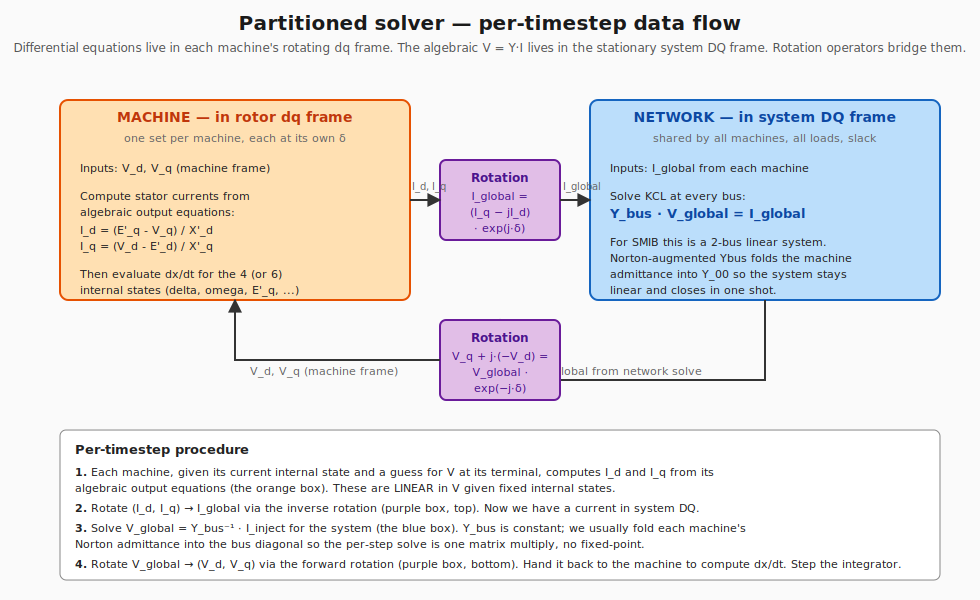

In [16]:
# Partitioned-solver block diagram.  Mirrors the data flow described
# above: differential side in machine dq, algebraic side in system DQ,
# rotation operators bridging the two each step.
from IPython.display import SVG, display
display(SVG(filename='figs/partitioned_solver.svg'))


**The same flow, in pseudocode.**  Read the body of `simulator.py`
alongside this — every line below maps to one or two lines in the
real solver.

```text
# State carried across timesteps:
#   x = (delta, omega_bar)      # differential, in machine dq
#   y = (V_bus, I_inject)       # algebraic, in system DQ

for t = 0, h, 2h, ..., t_end:

    # -------- 1. PREDICTOR (explicit Euler guess) ---------------
    f_old   = swing_eq(x, y)                    # uses (V, I) at start of step
    x_guess = x + h * f_old

    # -------- 2. CORRECTOR LOOP --------------------------------
    repeat:

        # 2a. Bridge:  rotor state -> machine internal EMF in system DQ
        E_global = |E'| * exp(j * x_guess.delta)

        # 2b. Algebraic side:  one-shot Norton solve for V_bus
        #     (Y_aug = Y_bus + machine internal admittance, prefactored)
        V_bus    = Y_aug \ ( I_norton(E_global) - Y_01 * V_inf )
        I_inject = (E_global - V_bus) / (j * X'd)

        # 2c. Differential side:  swing-equation slope at the new state
        f_new    = swing_eq(x_guess, (V_bus, I_inject))

        # 2d. Trapezoidal update — average of slopes
        x_new    = x + (h/2) * (f_old + f_new)

        if max(|x_new - x_guess|) < tol: break
        x_guess = x_new

    # -------- 3. ACCEPT, advance time ---------------------------
    x = x_new ; y = (V_bus, I_inject)
```

A few features worth noting on the diagram and pseudocode together:

- **Steps 2a–2c are the partition.**  2a + 2b is the algebraic
  solve (one shot for index-1 SMIB).  2c is the differential
  evaluation.  They run in series, not simultaneously — that's what
  makes the scheme *partitioned*.
- **The corrector loop is steps 2a–2d.**  It repeats because
  `f_new` depends on `x_guess`, which depends on `f_new`.  For
  GENCLS we converge in 2–3 passes; for GENROU+AVR+PSS, 3–5.
- **The Norton trick lives on line 2b.**  $1/(jX'_d)$ has been
  folded into $Y_\text{aug}[0,0]$ once at init time.  Per timestep
  the algebraic solve is a single linear back-substitution, no
  inner Newton.
- **The rotation $E'_\text{global} = |E'|\,e^{j\delta}$ on line 2a
  is the only place the two frames touch.**  Everything to the
  right of it is in system DQ.  Everything to the left (the rotor
  state, the swing equation) lives in the machine's rotating dq
  frame.  Detailed picture in
  [`docs/network_machine_interface.md`](../docs/network_machine_interface.md).

### 10.3 Concrete walkthrough — where does the current injection come from?

Worth being painfully explicit about this because it's the *exact*
bridge between the differential side (which lives in the machine
dq frame, parameterised by the rotor state) and the algebraic side
(which lives in the network DQ frame, where $Y_\text{bus}$ is
constant).  Here is what happens for **one GENCLS timestep** at
our SMIB scenario, frame by frame:

**Step A — start of timestep $t_k$.**  The model's state is
$(\delta_k, \bar\omega_k)$.  These are scalars; $\delta_k$ is the
rotor angle measured in the system DQ frame (i.e. the angle of the
machine's q-axis relative to the system synchronous reference).
$\bar\omega_k$ is per-unit slip, frame-invariant.  $|E'|$ is held
constant by the GENCLS assumption.

**Step B — express the rotor's internal EMF in the system frame.**
By definition, in the machine dq frame, $E'$ lies on the q-axis:
$E'_\text{machine} = |E'| \cdot e^{j 0} = |E'|$ on the real axis.
Rotate to system DQ via the inverse of our standard rotation:

$$ E'_\text{global} = |E'| \cdot e^{j\delta_k} $$

For GENCLS this is the *only* piece of "machine frame" information
that crosses the bridge — because $|E'|$ is constant and there's no
$E'_d$ to worry about.  $\delta_k$ does all the work.

**Step C — solve for the bus voltage $V$.**  The network expects an
admittance-form KCL at every bus.  At our gen bus 0:

$$ Y_{00}\,V_0 + Y_{01}\,V_\infty = I_\text{inject,gen} $$

The current the gen injects depends on $V_0$ (via the algebraic
output equation $I = (E' - V)/(jX'_d)$ ), so we substitute and use
the Norton trick:

$$ I_\text{inject}(V_0) = E'/(jX'_d) - V_0/(jX'_d) = I_\text{N} - Y_\text{N}\,V_0 $$

Substituting:

$$ (Y_{00} + Y_\text{N})\,V_0 = I_\text{N} - Y_{01}\,V_\infty $$

This is **one matrix equation in one unknown** ($V_0$), solved in
closed form.  The rotor enters only through $E'_\text{global}$ from
Step B — that's where the differential side talks to the algebraic
side.

**Step D — compute the actual current injection.**  Now that $V_0$
is known:

$$ I_\text{inject,gen} = (E'_\text{global} - V_0) / (jX'_d) $$

This is a phasor in the system DQ frame.  This is the answer to
"where does the current injection come from" — it's
$(E'_\text{global} - V_0)/(jX'_d)$, evaluated *in the system frame*,
where $E'_\text{global}$ came from rotating the machine's internal
state and $V_0$ came from the network solve.

**Step E — get back to machine dq for the rotor's perspective.**  The
swing equation needs $P_e$, the electrical power.  Compute it
either in the system frame:

$$ P_e = \mathrm{Re}(V_0 \cdot I_\text{inject,gen}^*) $$

…or equivalently by rotating both into machine dq and using
$P_e = V_d I_d + V_q I_q$.  Both give the same scalar (power is
frame-invariant).

**Step F — evaluate $dx/dt$ for the rotor.**  Using $P_e$ from Step E:

$$ \dfrac{d\delta}{dt} = \omega_0 \bar\omega_k \qquad
   \dfrac{d\bar\omega}{dt} = (P_m - P_e - D\bar\omega_k)/(2H) $$

Both right-hand sides are now numbers.

**Step G — trapezoidal step forward** to get $(\delta_{k+1}, \bar\omega_{k+1})$,
running the corrector loop until the algebraic side and the
differential side agree at the new step.  Done — go back to Step A
with the new state.

The thing this walkthrough makes explicit: **the current injection
is computed in the system frame, but its dependence on
$\delta_k$ encodes everything we need to know about the rotor's
machine dq frame**.  The rotation $E'_\text{global} = |E'| e^{j\delta_k}$
is the bridge.  No time integration is involved in the rotation — it
is a *static algebraic* mapping each timestep.

For GENROU the bridge is a little wider because there are TWO
flux states ($E'_q$ and $E'_d$, both in machine dq) instead of just
$|E'|$.  We rotate the complex pair $E'_q - jE'_d$ to system DQ
the same way, and the network solve becomes a 2×2 linear system
because $X'_d \ne X'_q$ creates an *anisotropic* internal
admittance.  The Phase 2.0 notebook walks through this concretely.

### 10.4 What gets evaluated per timestep — the flowchart

Every dynamics result in this notebook is the output of a single
piece of plumbing: the implicit trapezoidal solver in `smib/solver.py`,
called once per 2 ms timestep by `smib/simulator.py`, which in turn
calls `gencls.derivatives()` (differential) and the network solve
(algebraic) and stitches them via the rotation.

Two things are worth being explicit about in the flowchart below:

1. **Where the swing equation is evaluated.** Twice per timestep at
   minimum — once at the start of the step (the "old slope" $f_0$),
   and once per corrector iteration as the integrator refines its
   guess for the end-of-step state (the "new slope" $f$).
2. **How those derivatives become state changes.** The trapezoidal
   rule averages the start and end slopes:
   $x_{\text{new}} = x_0 + (h/2)\,(f_0 + f)$.
   That single line is the whole numerical backbone — every plot in
   this notebook ultimately comes from many copies of it.

The flow chart traces one timestep end-to-end.

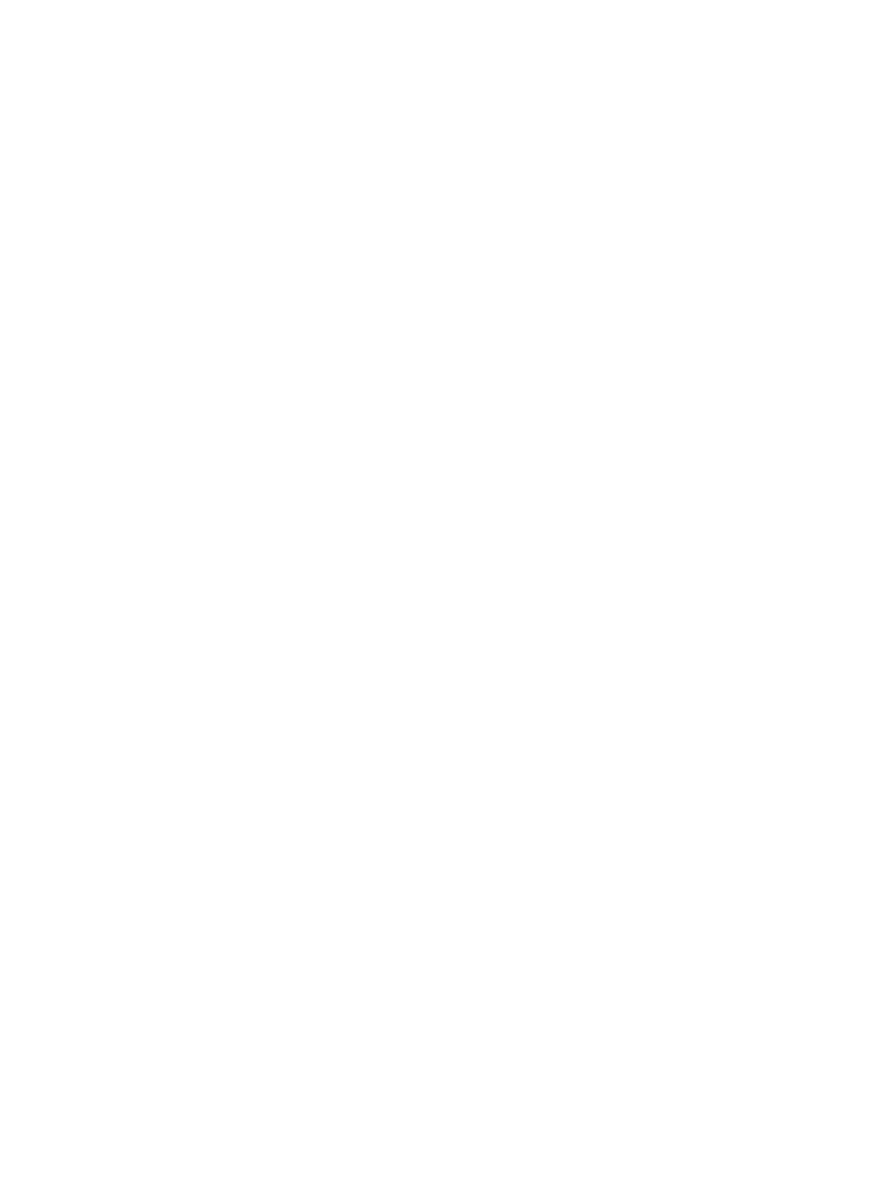

In [17]:
# Render the trapezoidal-integration flowchart.  We load the SVG from
# disk and let IPython.display do the rendering — this is more robust
# than embedding raw SVG inside a markdown cell, which some notebook
# front-ends sanitise away.
from IPython.display import SVG, display
display(SVG(filename='figs/trapezoidal_flow.svg'))

**Key takeaways for reading the rest of the notebook.**

- The swing equation $d\delta/dt = \omega_0\,\bar\omega$ and
  $d\bar\omega/dt = (P_m - P_e - D\bar\omega)/(2H)$ is evaluated
  **inside the orange boxes**.  These are the only two equations the
  integrator knows about for GENCLS.
- The state vector $(\delta, \bar\omega)$ is updated **inside the
  green boxes** — once as a coarse predictor, then refined by the
  corrector.  The trapezoidal update line
  $x_{\text{new}} = x_0 + (h/2)(f_0 + f)$ is the only place the
  state actually changes.
- The corrector loop runs 2-3 times per timestep for GENCLS,
  re-evaluating the swing equation each time.  For Phase 2 with
  GENROU + AVR + PSS + Gov we expect 3-5 iterations per step.
- The trapezoidal scheme is **second-order accurate** (error
  $\sim h^3$ per step) and **A-stable** (handles stiff systems
  without becoming numerically unstable).  PSSE uses the same
  integrator.  When our results disagree with PSSE we know it is
  the *model*, not the integrator.

## 11. Interactive — sweep inertia and fault duration

Drag the sliders.  Inertia $H$ controls how fast $\delta$ accelerates
under unbalanced power; the fault duration controls how much energy
gets pumped into the rotor.  Together they determine whether the rotor
returns or escapes — and that's exactly the equal-area criterion in
action.

If you wind $H$ down or the fault up far enough, you'll see $\delta$
escape past $\pi$ and the trace shoots upward.  That's the loss of
synchronism the CCT test bracketed above.

In [ ]:
def run_for_sliders(H, fault_ms):
    g = GENCLS(H=H, D=3.0, Xdp=0.30, f0=50.0)
    n = Network(R=R_line, X=X_line, V_slack_mag=abs(V_inf))
    g.initialise(V1, complex(P, Q))
    fault = three_phase_fault_schedule(1.0, 1.0 + fault_ms / 1000.0, 0.001 + 0j)
    r = run_smib_gencls(g, n, t_end=5.0, h=2e-3, scenarios=[fault])
    out = {k: r.traces[k] for k in CANONICAL}
    out['delta [deg]'] = np.degrees(r.traces['delta'])
    out['slip [pu]']   = r.traces['omega']
    return r.t, out

scenario_slider(
    run_for_sliders,
    sliders=[
        {'name': 'H',         'min': 1.0, 'max': 10.0, 'step': 0.5, 'value': 4.0,
         'description': 'Inertia H [s]'},
        {'name': 'fault_ms',  'min': 50,  'max': 400,  'step': 10,  'value': 100,
         'description': 'Fault duration [ms]'},
    ],
    title='GENCLS — three-phase fault sensitivity',
    extra_traces=('delta [deg]', 'slip [pu]'),
)

## 12. What's missing (Phase 2 onward)

The classical machine ignores everything that makes a real generator
interesting:

- No field flux dynamics → no `E'_q` evolution, no constant-flux-linkage
  step response on first swing.  We add this with **GENROU** in Phase 2.
- No AVR → field voltage `Efd` is locked at the value that produced
  `|E'|` at $t=0$.  Real machines respond to a fault by ramping `Efd`.
  We add **ST1A** in Phase 2.
- No PSS → no electrical damping of the swing; the only thing that
  damps in this notebook is the constant `D` term.  We add **PSS1A**
  in Phase 2.
- No governor → mechanical input never adjusts to a frequency
  deviation.  We add **TGOV1** in Phase 2.

Phase 2 wires all four together and re-runs the same fault scenarios.
Side-by-side comparison with this notebook will be the headline plot
of that phase.